# Import Libraries

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('..'))

from src.data_loader import load_train_data, load_test_data
from src.features import TitanicFeatureEngineer


# Load Raw Data

In [2]:
print("Loading raw data... ")
train_raw = load_train_data()
test_raw = load_test_data()

print(f"Raw Train Shape: {train_raw.shape}")
print(f"Raw Test shape: {test_raw.shape}")

Loading raw data... 
Raw Train Shape: (891, 12)
Raw Test shape: (418, 11)


# SPLIT THE RAW TRAIN DATA
### We split the raw data into two raw parts: Training and Validation.
### The Validation set is completely held out during feature engineering fitting.

In [3]:
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(train_raw, train_raw["Survived"], test_size=0.2, random_state=42)

# Drop the 'Survived' column from the raw features.
X_train_raw = X_train_raw.drop(columns=['Survived'])
X_val_raw = X_val_raw.drop(columns=['Survived'])

print(f"\n✅ Raw Train fold size: {X_train_raw.shape}")
print(f"✅ Raw Validation fold size: {X_val_raw.shape}")


✅ Raw Train fold size: (712, 11)
✅ Raw Validation fold size: (179, 11)


# Initialize & Fit Engineer (Only on X_train_raw)

In [4]:
engineer = TitanicFeatureEngineer()
engineer.fit(X_train_raw)

# Transform ALL sets using the SAME fitted engineer

In [5]:
train_processed = engineer.transform(X_train_raw, is_train=True)
val_processed = engineer.transform(X_val_raw, is_train=True)
test_processed = engineer.transform(test_raw, is_train=False)

d:\Programming\Python\titanic-project\venv\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
d:\Programming\Python\titanic-project\venv\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# Add the target back to train and val

In [6]:
train_processed["Survived"] = y_train_raw.values
val_processed["Survived"] = y_val_raw.values

print("\n✅ Processed Train shape:", train_processed.shape)
print("✅ Processed Validation shape:", val_processed.shape)
print("✅ Processed Test shape:", test_processed.shape)


✅ Processed Train shape: (712, 23)
✅ Processed Validation shape: (179, 23)
✅ Processed Test shape: (418, 23)


# Save Processed Data (for model training later)

In [7]:
train_processed.to_csv('../data/processed/train_processed.csv', index=False)
val_processed.to_csv('../data/processed/val_processed.csv', index=False)
test_processed.to_csv('../data/processed/test_processed.csv', index=False)

print("\n💾 Processed data saved to 'data/processed/'")


💾 Processed data saved to 'data/processed/'


# Sanity Check: No missing values?

In [8]:
print(f"\nMissing values in Train: {train_processed.isnull().sum().sum()}")
print(f"Missing values in Val: {val_processed.isnull().sum().sum()}")
print(f"Missing values in Test: {test_processed.isnull().sum().sum()}")


Missing values in Train: 0
Missing values in Val: 0
Missing values in Test: 0


# Quick correlation check on train

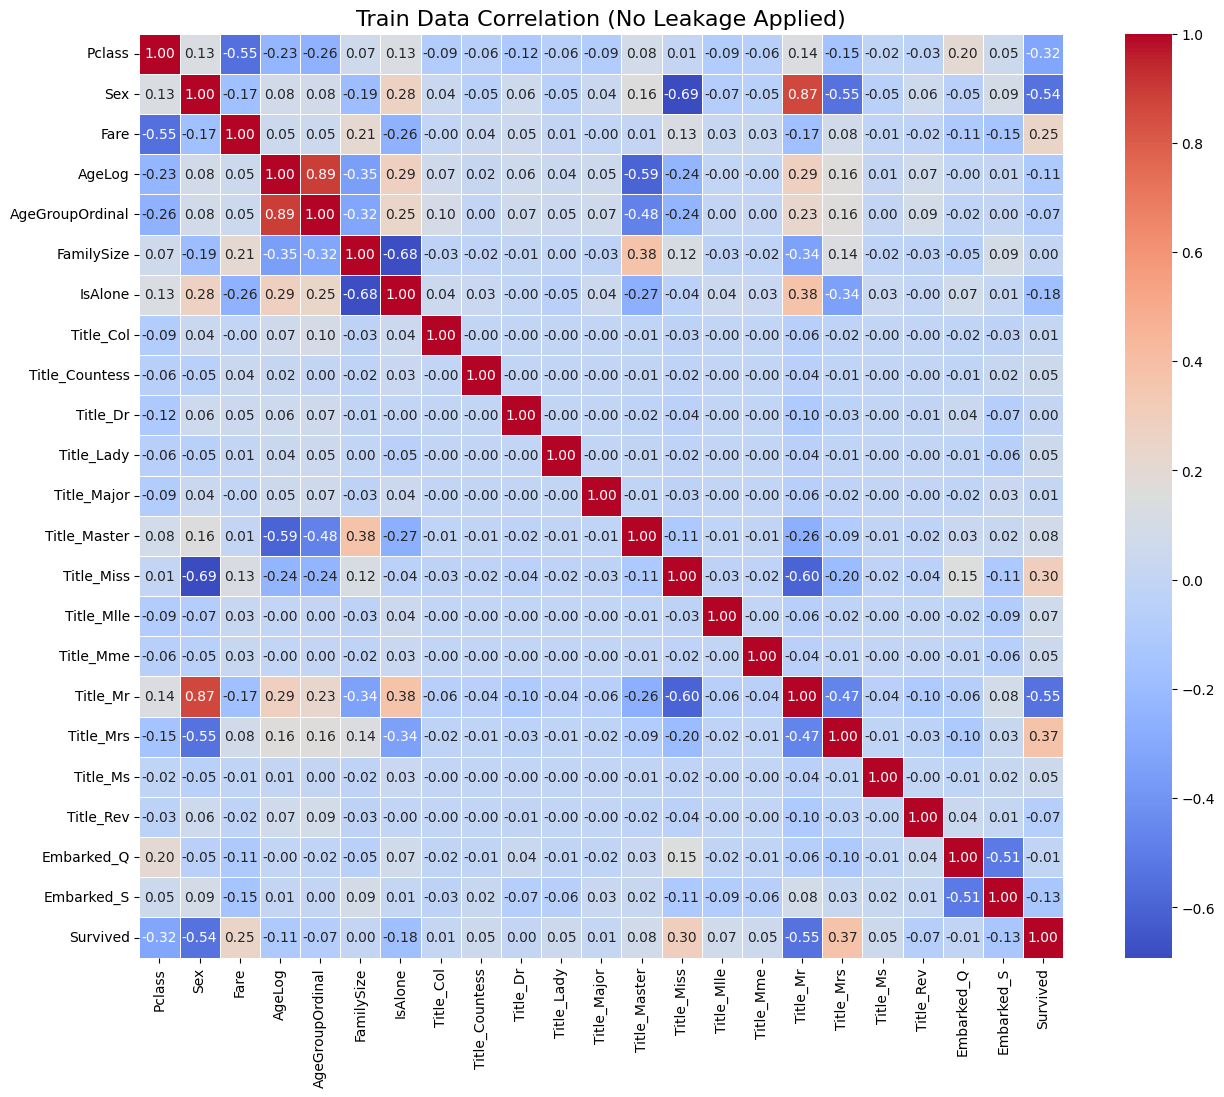

In [9]:
plt.figure(figsize=(16, 12))
sns.heatmap(train_processed.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Train Data Correlation (No Leakage Applied)', fontsize=16)
plt.show()